[2026-04-26 19:16:24 | +0.0s] ファイル検索開始
[2026-04-26 19:16:24 | +0.0s] 最新ファイル検出: change_point_pairs_pelt_rbf_20260418_102306.csv
[2026-04-26 19:16:24 | +0.0s] CSV読み込み開始
[2026-04-26 19:16:30 | +5.5s] 読み込み完了: 行数=609
[2026-04-26 19:16:30 | +5.5s] datetime変換
[2026-04-26 19:16:30 | +5.6s] datetime有効行: 609 (削除: 0)
[2026-04-26 19:16:30 | +5.6s] 日付集計
[2026-04-26 19:16:30 | +5.7s] 日数: 94
[2026-04-26 19:16:30 | +5.7s] プロット開始


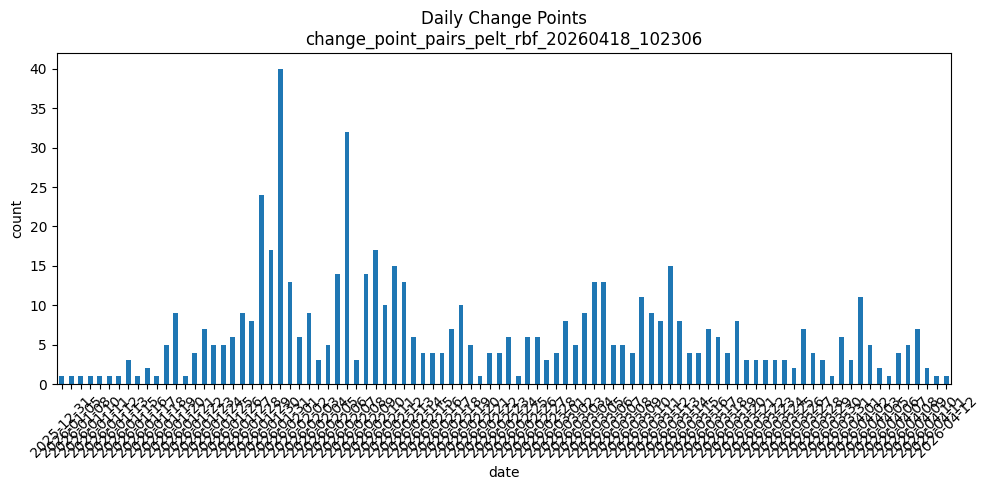

[2026-04-26 19:16:32 | +7.6s] 完了


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

# =========================================
# 0. ログ関数
# =========================================
START_TIME = datetime.now()

def log(msg):
    now = datetime.now()
    elapsed = (now - START_TIME).total_seconds()
    print(f"[{now.strftime('%Y-%m-%d %H:%M:%S')} | +{elapsed:.1f}s] {msg}")

# =========================================
# 1. カレントディレクトリから最新CSV取得
# =========================================
log("ファイル検索開始")

current_dir = Path(".")
files = list(current_dir.glob("change_point_pairs_pelt_rbf_*.csv"))

if not files:
    raise FileNotFoundError("対象ファイルが見つかりません")

# 更新日時で最新取得
file_path = max(files, key=lambda f: f.stat().st_mtime)

log(f"最新ファイル検出: {file_path}")

# =========================================
# 2. CSV読み込み
# =========================================
log("CSV読み込み開始")

df = pd.read_csv(
    file_path,
    skiprows=1,
    names=["coin", "datetime", "score"]
)

log(f"読み込み完了: 行数={len(df)}")

# =========================================
# 3. datetime変換
# =========================================
log("datetime変換")

df["datetime"] = pd.to_datetime(
    df["datetime"],
    format="%Y-%m-%d %H:%M:%S",
    errors="coerce"
)

before = len(df)
df = df.dropna(subset=["datetime"])
after = len(df)

log(f"datetime有効行: {after} (削除: {before-after})")

# =========================================
# 4. 日付ごと集計
# =========================================
log("日付集計")

df["date"] = df["datetime"].dt.date
daily_counts = df.groupby("date").size().sort_index()

log(f"日数: {len(daily_counts)}")

# =========================================
# 5. タイトル用ファイル名整形
# =========================================
file_name = file_path.stem  # 拡張子なし

# 長い場合は短縮
if len(file_name) > 60:
    file_name = file_name[:60] + "..."

# =========================================
# 6. プロット
# =========================================
log("プロット開始")

plt.figure(figsize=(10, 5))

daily_counts.plot(kind="bar")

plt.xlabel("date")
plt.ylabel("count")

# ★ ファイル名をタイトルに表示
plt.title(f"Daily Change Points\n{file_name}")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

log("完了")